# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Completa aquí] ¿Qué debes hacer con esta variable email?
# ¿Qué hace el código? En una variable configuramos el email del usuario de Databricks
# ¿Por qué es importante? Posteriormente se va a utilizar para contruir la ruta de nuestro experimento
# ¿Qué resultado esperamos?
email = 'jiehaoxu1@gmail.com'  # ⚠️ CAMBIAR POR TU EMAIL DE DATABRICKS

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    
    # TODO: [Completa aquí] ¿Para qué sirve set_tracking_uri?
    # ¿Qué hace el código? Configura Databricks como servidor de tracking de MLflow
    # ¿Por qué es importante? Permite registrar de forma centralizada los runs, parámetros, métricas y artefactos de los experimentos
    # ¿Qué resultado esperamos? Esperamos que MLflow utilice el workspace de Databricks para guardar los experimentos.
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [Completa aquí] ¿Qué hace set_experiment?
    # ¿Qué hace el código? Define y selecciona el experimento de MLflow que se va a utilizar.
    # ¿Por qué es importante? Permite organizar todos los runs relacionados dentro de un mismo experimento.
    # ¿Qué resultado esperamos? Esperamos que se cree o seleccione el experimento
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/jiehaoxu1@gmail.com/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
# ¿Qué hace el código? Es una función que permite dividir un dataset
# ¿Por qué es importante? Es importante para dividir los datos en un conjunto de entrenamiento y otro de prueba.
# ¿Qué resultado esperamos? Esperamos que se divida el dataset en dos conjuntos
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
# ¿Qué hace el código? Poder crear flujos que agrupen varios pasos.
# ¿Por qué es importante? Permite agrupar en un solo flujo los pasos de preprocesamiento y entrenamiento del modelo.
# ¿Qué resultado esperamos? Crear un pipeline que ejecute los pasos definidos de forma ordenada y automática.
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
# Stochastic Gradient Descent. Entrena un modelo lineal actualizando sus pesos para corregir los errores
# Algoritmo basado en muchos árboles de decisión. Entrena muchos árboles de decisión y somete la decisión a votación. Utilizar un único árbol no es suficiente porque puede sobreajustarse.
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
# ¿Qué hace el código? Entrenar el modelo con varias divisiones del dataset.
# ¿Por qué es importante? Sirve para evaluar el modelo varias veces usando validación cruzada.
# ¿Qué resultado esperamos? Saber el rendimiento promedio del modelo
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
# Precision indica cuántas de las predicciones positivas fueron realmente positivas.
# Recall indica cuántos casos positivos reales fue capaz de detectar el modelo.
# F1-score combina precision y recall en una sola métrica.
# ROC-AUC mide la capacidad del modelo para distinguir entre las dos clases.
# También utilizaremos la matriz de confusión y el classification report para analizar con más detalle los aciertos y errores del modelo.
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# TODO: Carga los datos y explica qué contiene el archivo.
# ¿Qué hace el código? Carga el archivo CSV heart.csv desde la ruta indicada.
# ¿Por qué es importante? Permite acceder al dataset que utilizaremos para entrenar y evaluar el modelo.
# ¿Qué resultado esperamos? Guardar en csv en un dataframe
data = pd.read_csv('../data/raw/heart.csv')

# TODO: Muestra número de filas, columnas y variable objetivo.

print(f"Número de muestras: {len(data)}")
print(f"Número de características: {len(data.columns) - 1}")  # -1 porque target no es característica
print(f"Variable objetivo: target (0 = No enfermedad, 1 = Enfermedad)")

Número de muestras: 303
Número de características: 13
Variable objetivo: target (0 = No enfermedad, 1 = Enfermedad)


In [0]:
# TODO: Muestra las primeras filas con head().
# TODO: Explica por qué esta inspección es útil antes de modelar.
# ¿Qué hace el código? Mostrar las columnas que posee y las 5 primeras filas de datos
# ¿Por qué es importante? Permote ver que el dataset se ha cargado de una forma correcta.
# ¿Qué resultado esperamos? Una preview con los datos
data.head()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# TODO: Usa info() para revisar tipos de datos y valores nulos.
data.info()

# TODO: Anota qué columnas parecen categóricas y cuáles numéricas.
# Columnas categóricas: sex, cp, fbs, restecg, exang, slope, ca, thal, target.
# Columnas numéricas: age, trestbps, chol, thalach, oldpeak.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# TODO: Usa describe() para obtener estadísticas descriptivas.
data.describe()

# TODO: Escribe observaciones sobre rangos, medias y posibles valores atípicos.
# La edad va de 29 a 77 años, con una media aproximada de 54 años.
# trestbps tiene una media de 131.5 y valores entre 94 y 200; los valores altos podrían ser atípicos.
# chol presenta una media de 245.9 y un máximo de 564, bastante alejado del 75% (275), por lo que puede haber outliers.
# thalach tiene una media de 149.6 y valores entre 71 y 202; los valores muy bajos podrían ser atípicos.
# oldpeak tiene una media de 1.04 y un máximo de 6.2, por lo que también podría contener valores atípicos altos.
# Además, trestbps y chol tienen valores nulos, ya que sus counts son menores que 303.


,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes
- El rango de valores de cada característica
- La presencia de valores nulos
- Características que pueden necesitar normalización

In [0]:
# TODO: Analiza la distribución de la variable objetivo.
target_counts = data.target.value_counts()
print(target_counts)

# TODO: Calcula proporciones por clase.
# TODO: Decide si el dataset está balanceado y explica por qué importa.
# El dataset está bastante balanceado: la clase 1 representa aproximadamente el 54.5%
# y la clase 0 aproximadamente el 45.5%.
# Esto es importante porque un fuerte desbalance podría hacer que el modelo favorezca
# la clase mayoritaria y que métricas como accuracy resulten engañosas.



target
1    165
0    138
Name: count, dtype: int64


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

In [0]:
cp_target = pd.crosstab(
    data['cp'],
    data['target'],
    normalize='index'
) * 100
print(cp_target)

target                    0          1
cp                                    
asymptomatic      30.434783  69.565217
atypical angina   18.000000  82.000000
non-anginal pain  20.689655  79.310345
typical angina    72.727273  27.272727


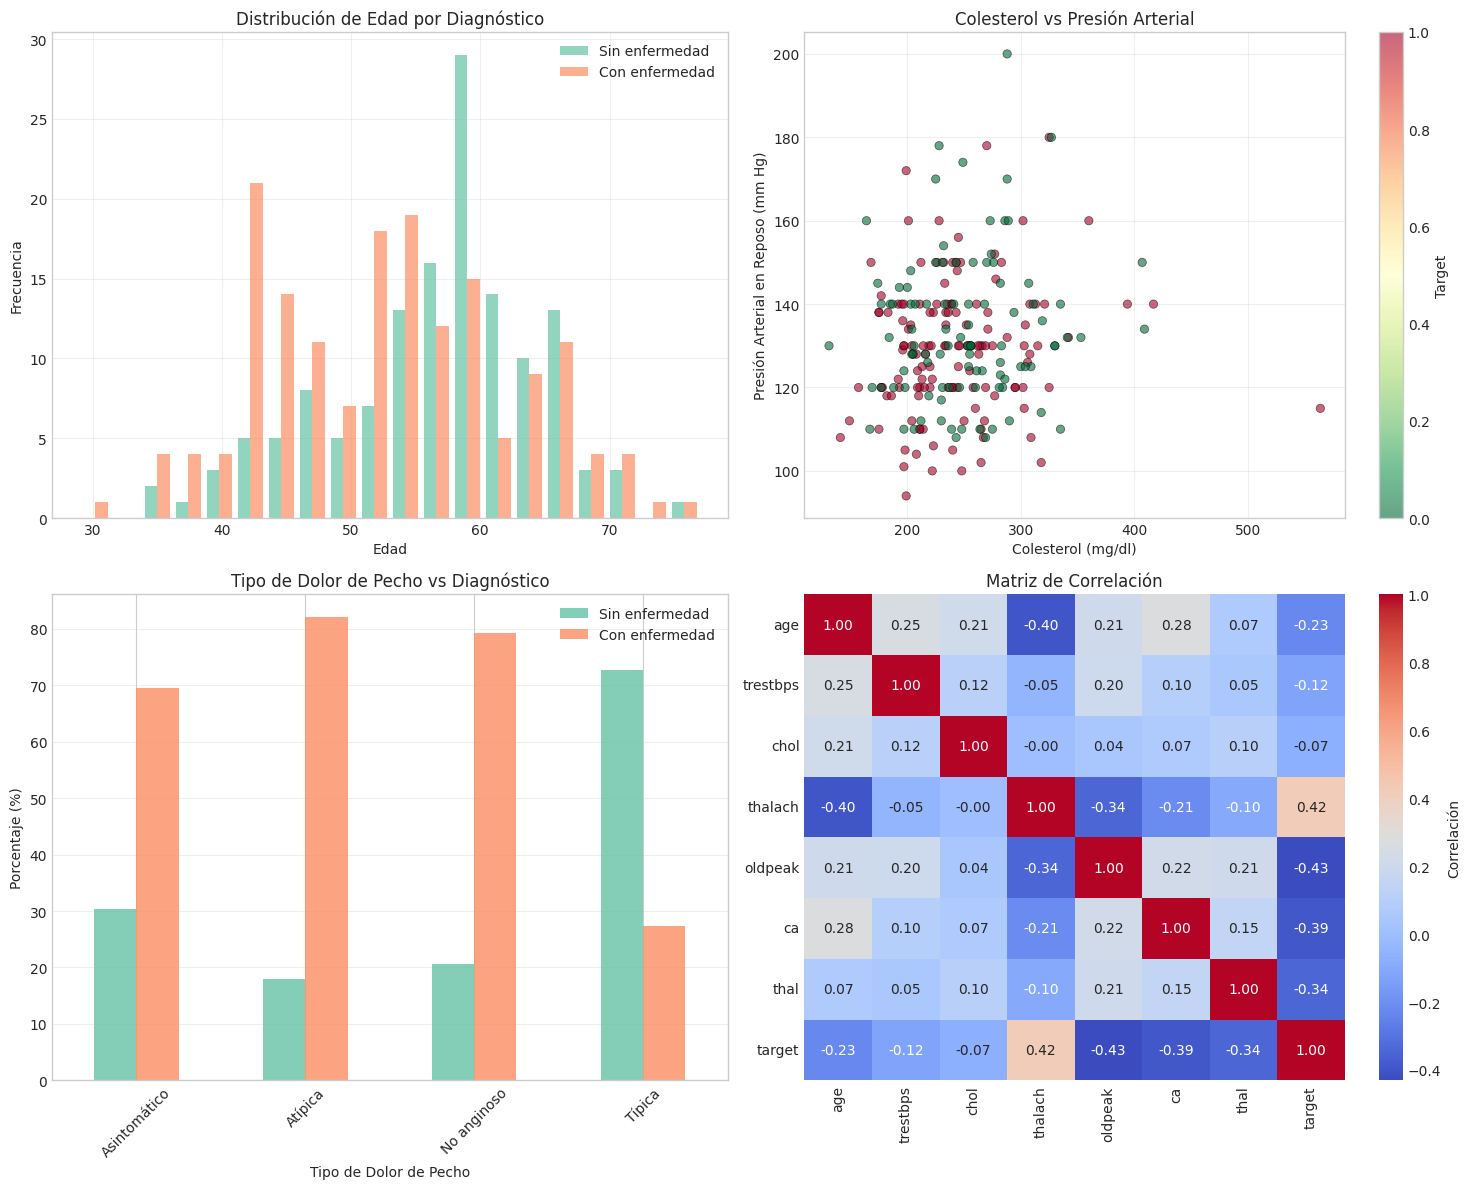

In [0]:
# TODO: Crea visualizaciones para explorar patrones del dataset.
# Ideas:
# - Distribución de edad por diagnóstico
# - Colesterol vs presión arterial coloreado por target
# - Tipo de dolor de pecho vs diagnóstico
# - Matriz de correlación

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# Gráfico 1: Distribución de edad por target
axes[0, 0].hist([data[data.target==0]['age'], data[data.target==1]['age']], 
                bins=20, label=['Sin enfermedad', 'Con enfermedad'], alpha=0.7)
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Edad por Diagnóstico')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Colesterol vs Presión Arterial
scatter = axes[0, 1].scatter(data['chol'], data['trestbps'], c=data['target'], 
                             alpha=0.6, cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Colesterol (mg/dl)')
axes[0, 1].set_ylabel('Presión Arterial en Reposo (mm Hg)')
axes[0, 1].set_title('Colesterol vs Presión Arterial')
plt.colorbar(scatter, ax=axes[0, 1], label='Target')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Tipo de dolor de pecho por diagnóstico
# Da el orden alfabetico 
cp_target = pd.crosstab(data['cp'], data['target'], normalize='index') * 100
cp_target.plot(kind='bar', ax=axes[1, 0], alpha=0.8)
axes[1, 0].set_xlabel('Tipo de Dolor de Pecho')
axes[1, 0].set_ylabel('Porcentaje (%)')
axes[1, 0].set_title('Tipo de Dolor de Pecho vs Diagnóstico')
axes[1, 0].legend(['Sin enfermedad', 'Con enfermedad'])
axes[1, 0].set_xticklabels( ['Asintomático', 'Atípica', 'No anginoso', 'Típica'], rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Gráfico 4: Matriz de correlación de características númericas
top_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal', 'target']
corr_matrix = data[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1, 1], cbar_kws={'label': 'Correlación'})
axes[1, 1].set_title('Matriz de Correlación')
plt.tight_layout()
plt.show()

# TODO: Escribe qué patrones observas en los gráficos.
# La presencia de enfermedad cardíaca se concentra notablemente en edades de 40 a 55 años y muestra una fuerte asociación con tipos de dolor no anginoso, atípico y asintomático, mientras que el dolor típico predomina en pacientes sanos. En la correlación, la frecuencia cardíaca máxima se asocia positivamente con el diagnóstico, en contraste con oldpeak  y ca  que muestran relación inversa, mientras que variables clínicas como el colesterol y la presión arterial en reposo presentan baja correlación lineal y una dispersión sin separación clara.

## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Divide los datos en train y test.
# Pistas:
# - Usa train_test_split
# - Define test_size
# - Usa random_state para reproducibilidad

train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

# TODO: Comprueba el tamaño de cada conjunto.
print("Conjunto de entranamiento:", train_set.shape)
print("Conjunto de test:" , test_set.shape)


Conjunto de entranamiento: (242, 14)
Conjunto de test: (61, 14)


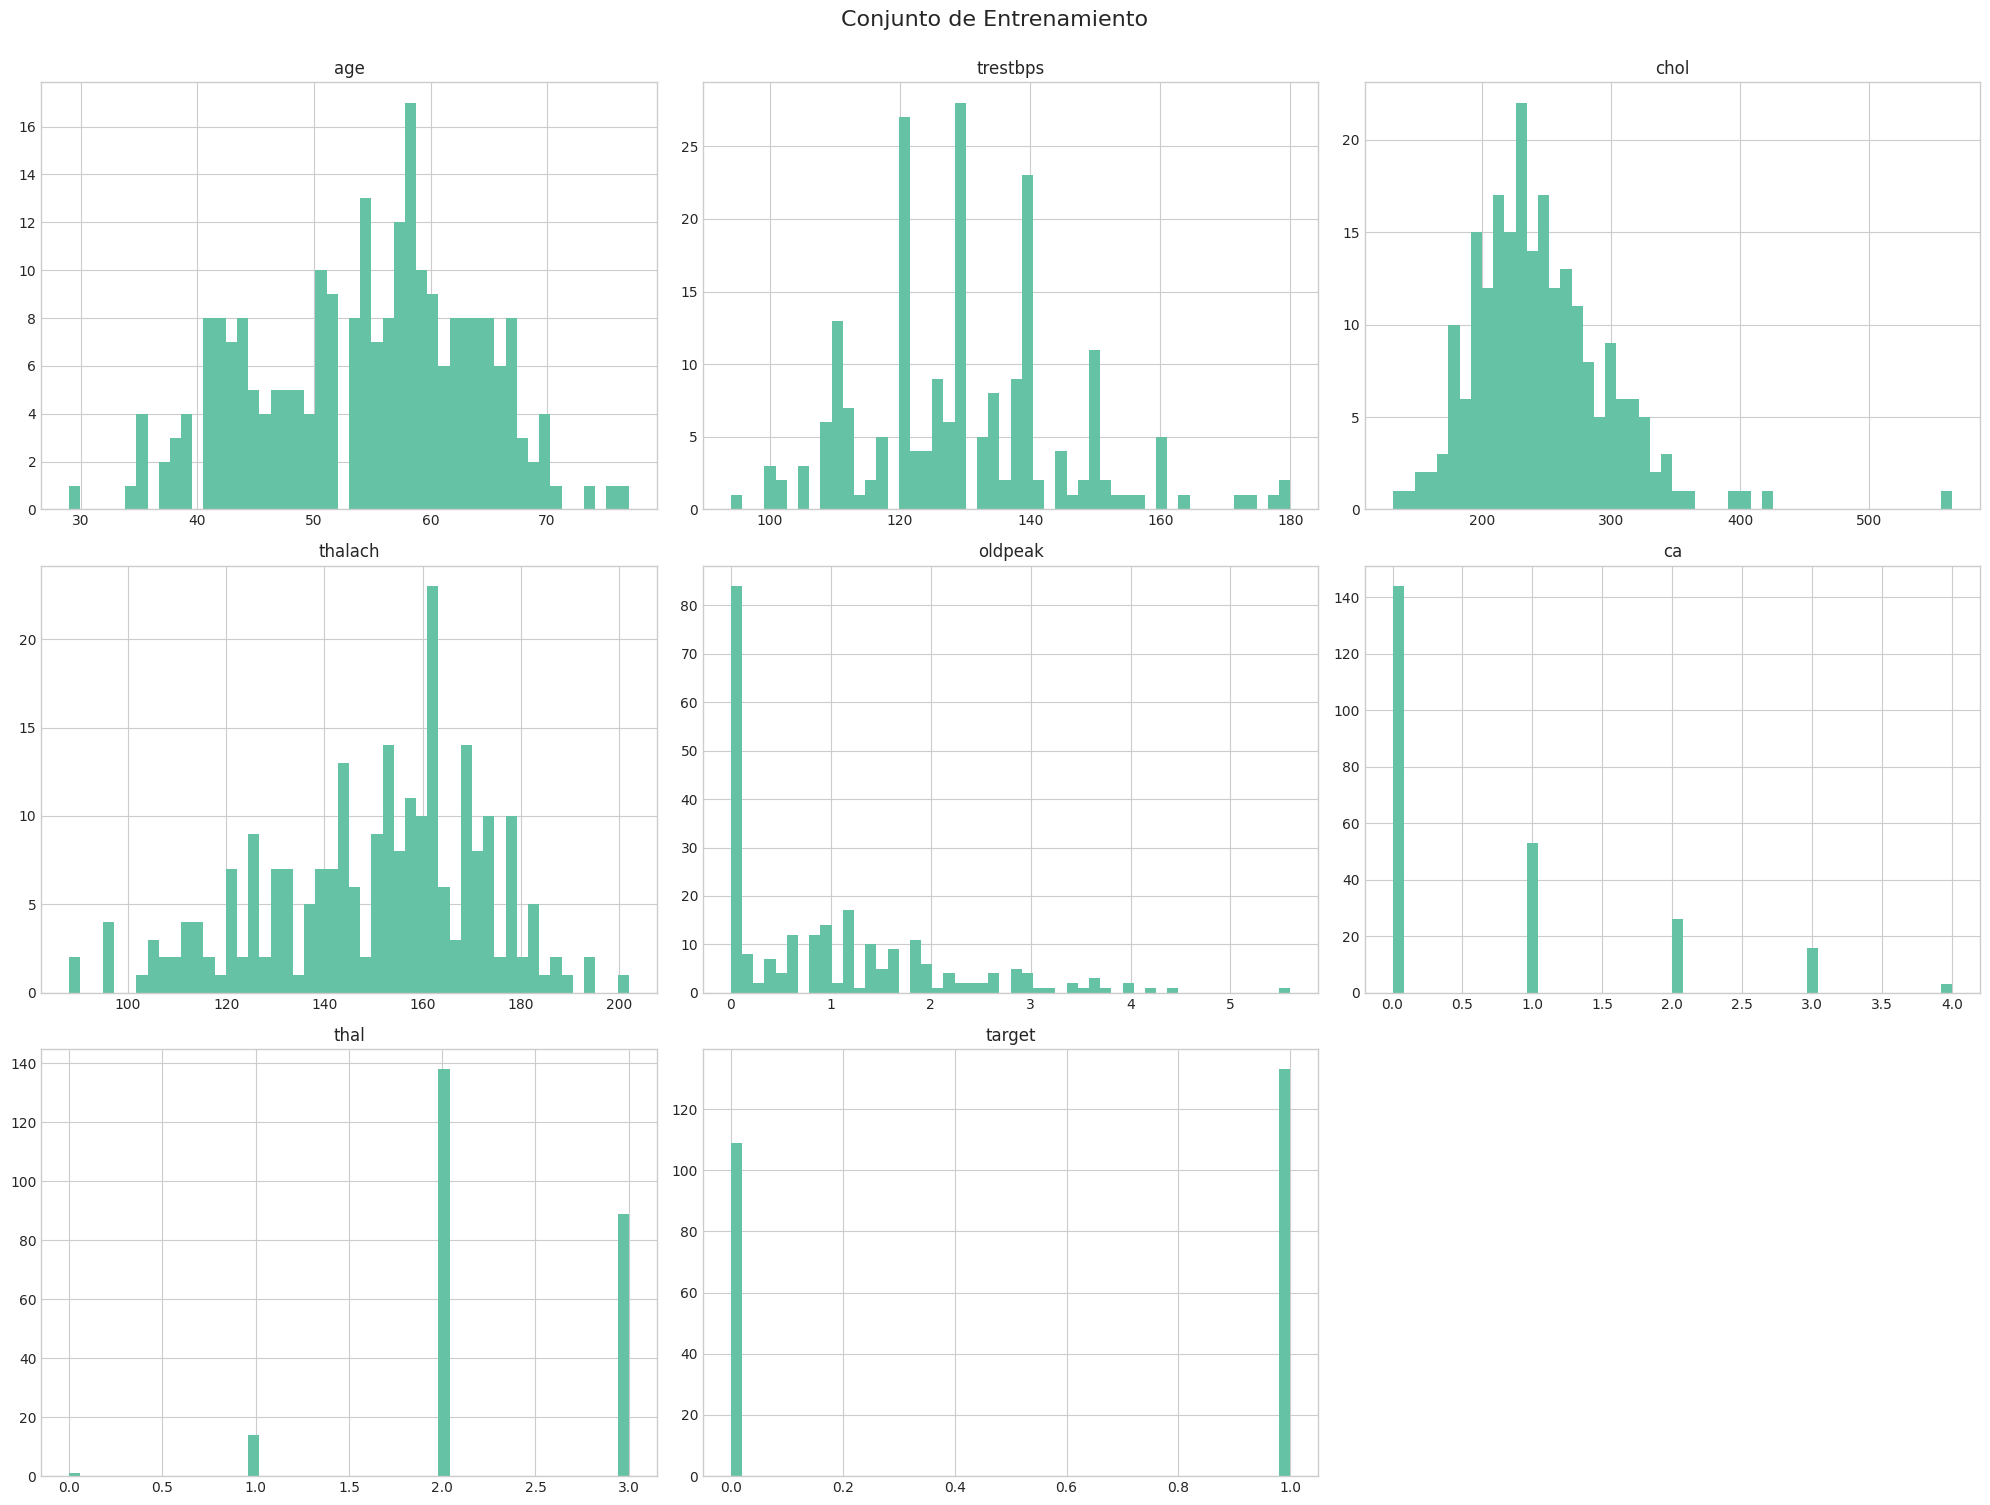

In [0]:
# TODO: Genera histogramas del conjunto de entrenamiento.
# train_set.hist(bins=50, figsize=(20, 15))
# plt.show()
train_set.hist(bins=50, figsize=(20, 15))
plt.suptitle('Conjunto de Entrenamiento', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()
# TODO: Identifica características con escalas o distribuciones muy diferentes.
# Algunas características tienen distribuciones muy diferentes.
# oldpeak presenta una distribución muy asimétrica y concentrada cerca de 0.
# ca, thal y target son variables discretas, por lo que aparecen como picos en valores concretos.
# chol también presenta valores atípicos altos, mientras que age, trestbps y thalach
# tienen distribuciones más continuas.


### 📏 Observación Importante: Escalas Diferentes

**TODO: [Completa aquí] ¿Por qué es un problema que las características tengan escalas diferentes?**
Porque muchos algoritmos comparan o combinan numéricamente las características, y una variable con valores mucho más grandes puede influir más solo por su escala.

Revisa columnas como `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.

**TODO: [Completa aquí] ¿Qué transformación aplicarías para que las variables numéricas sean comparables?**
Aplicaría una estandarización de las variables numéricas, para que tengan media 0 y desviación estándar 1.

**TODO: [Completa aquí] ¿Por qué esto ayuda a algunos modelos de Machine Learning?**
Porque pone todas las características en una escala comparable, evitando que las variables con valores numéricos más grandes tengan más influencia simplemente por su escala.

## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# TODO: Clasifica las columnas en categóricas y numéricas.
cat_attr = ["sex", "cp", "fbs", "restecg", "exang", "slope"]
num_attr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal"]

# TODO: Crea un pipeline para variables numéricas.
# Pistas:
# - SimpleImputer para valores nulos
# - StandardScaler para estandarizar
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  
    ("std_scaler", StandardScaler())                
])

# TODO: Crea un ColumnTransformer que combine numéricas y categóricas.
# Pista: usa OneHotEncoder para variables categóricas.
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attr),      
    ("cat", OneHotEncoder(), cat_attr)    
])

# TODO: Explica por qué usamos One-Hot Encoding para categóricas.
# Convierte variables categóricas de texto en columnas numéricas binarias para que un modelo pueda trabajar con ellas.


## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# TODO: Separa características (X) y target (y) del conjunto de entrenamiento.
x_train = train_set.drop("target", axis=1)  
y_train = train_set.target                  

# TODO: Comprueba las dimensiones resultantes.
print(f"X_train shape: {x_train.shape} (características)")
print(f"y_train shape: {y_train.shape} (target)")


X_train shape: (242, 13) (características)
y_train shape: (242,) (target)


In [0]:
# TODO: Aplica el pipeline al conjunto de entrenamiento.
x_train_pr = full_pipeline.fit_transform(x_train)

# TODO: Explica la diferencia entre fit_transform y transform.
# La diferencia está en que fit_transform aprende y transforma, mientras que transform solo transforma.
# TODO: Comprueba cómo cambia el número de columnas.
feature_names = full_pipeline.get_feature_names_out()

x_train_pr_df = pd.DataFrame(
    x_train_pr,
    columns=feature_names
)

pd.set_option("display.max_columns", None)

print(x_train_pr_df.head())


   num__age  num__trestbps  num__chol  num__thalach  num__oldpeak   num__ca  \
0 -1.356798      -0.681777   0.971140      0.532781     -0.920864 -0.689701   
1  0.385086       1.371189   0.482501     -1.753582     -0.193787 -0.689701   
2 -0.921327       1.371189  -0.279776     -0.139679      2.350982 -0.689701   
3  0.058483       0.002545   0.091590      0.487950      0.351521 -0.689701   
4  0.602822      -0.887073  -0.299322      0.443119      0.351521  1.333421   

   num__thal  cat__sex_Female  cat__sex_Male  cat__cp_asymptomatic  \
0  -0.509048              0.0            1.0                   0.0   
1   1.178480              0.0            1.0                   0.0   
2  -0.509048              0.0            1.0                   0.0   
3  -0.509048              1.0            0.0                   0.0   
4   1.178480              0.0            1.0                   0.0   

   cat__cp_atypical angina  cat__cp_non-anginal pain  cat__cp_typical angina  \
0                      1

## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# TODO: Activa autolog de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run para el modelo baseline SGD.
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
#     TODO: Crea SGDClassifier.
    sgd_clf = SGDClassifier(random_state=42)
#     TODO: Evalúa con cross_val_score.
    scores = cross_val_score(sgd_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
#
#     TODO: Registra métricas de validación cruzada en MLflow.
    mlflow.log_metric("cv_accuracy_mean", scores.mean())
    mlflow.log_metric("cv_accuracy_std", scores.std())
#
#     TODO: Interpreta el resultado obtenido.
print("Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())
# El modelo obtiene una accuracy media de aproximadamente 76%. La desviación estándar es de aproximadamente 0.04, lo que indica una variabilidad moderada entre los distintos folds. Por tanto, el SGDClassifier ofrece un rendimiento baseline razonablemente estable, aunque todavía existe margen de mejora.


2026/09/27 15:23:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 15:23:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 15:23:48 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/09/27 15:23:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-ea0f21a9-b44d.cloud.databricks.com/ml/experiments/813163411252743/models/m-f65d3464300b4794ab3c9c01aae46ab9?o=7474652659743179
2026/09/27 15:23:52 WARNING mlflow.tr

Scores: [0.75308642 0.71604938 0.8125    ]
Mean: 0.7605452674897119
Std: 0.039727456507075834


### 📊 Evaluación del Modelo SGD

In [0]:
# TODO: Obtén predicciones con validación cruzada.
preds = cross_val_predict(sgd_clf, x_train_pr, y_train, cv=3)

# TODO: Explica por qué cross_val_predict es útil para construir métricas y matriz de confusión.
# Porque cross_val_predict() te da una predicción para cada muestra usando un modelo que no fue entrenado con esa muestra concreta


2026/09/27 15:22:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 15:22:11 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '03481e1d12ea4f4f8e52d7060d72f673', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/27 15:22:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 15:22:11 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/09/27 15:22:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

target
1    133
0    109
Name: count, dtype: int64
1    143
0     99
Name: count, dtype: int64


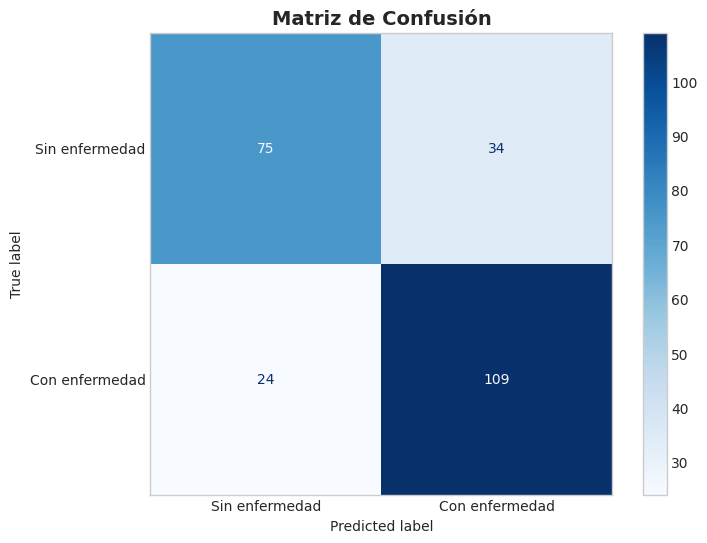

   TN (Verdaderos Negativos): 75 - Correctamente identificados como sanos
   FP (Falsos Positivos): 34 - Sanos clasificados como enfermos
   FN (Falsos Negativos): 24 - Enfermos clasificados como sanos ⚠️
   TP (Verdaderos Positivos): 109 - Correctamente identificados como enfermos


In [0]:
# TODO: Calcula y visualiza la matriz de confusión del modelo SGD.
# cm = confusion_matrix(...)
# disp = ConfusionMatrixDisplay(...)
# disp.plot(...)
# plt.show()
print(y_train.value_counts())
print(pd.Series(preds).value_counts())
      
cm = confusion_matrix(y_train, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

# TODO: Interpreta TN, FP, FN y TP.
print(f"   TN (Verdaderos Negativos): {cm[0,0]} - Correctamente identificados como sanos")
print(f"   FP (Falsos Positivos): {cm[0,1]} - Sanos clasificados como enfermos")
print(f"   FN (Falsos Negativos): {cm[1,0]} - Enfermos clasificados como sanos ⚠️")
print(f"   TP (Verdaderos Positivos): {cm[1,1]} - Correctamente identificados como enfermos")
# TODO: ¿Qué tipo de error es más grave en medicina?
# El error más grave en la medicina es el de falsos negativos, ya que significa que un paciente enfermo no ha sido diagnosticado correctamente y puede recibir tratamiento incorrecto o no recibir tratamiento necesario. Esto puede tener consecuencias graves para la salud del paciente

In [0]:
# TODO: Calcula métricas del modelo SGD.
precision = precision_score(y_train, preds)
recall = recall_score(y_train, preds)
f1 = f1_score(y_train, preds)
roc_auc = roc_auc_score(y_train, preds)

# TODO: Imprime e interpreta las métricas.
# TODO: ¿Qué métrica es más importante en medicina y por qué?
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"\nRecall: {recall:.4f} ({recall*100:.2f}%)")
print(f"\nF1 Score: {f1:.4f}")
print(f"\n📈 ROC-AUC Score: {roc_auc:.4f}")
# En este problema, Recall es especialmente importante porque interesa detectar la mayor cantidad posible de pacientes realmente enfermos y reducir los falsos negativos.

Precision: 0.7622 (76.22%)

Recall: 0.8195 (81.95%)

F1 Score: 0.7899

📈 ROC-AUC Score: 0.7538


### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# TODO: Entrena y evalúa un Random Forest en un nuevo run de MLflow.
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    rf_clf = RandomForestClassifier(random_state=42)
    rf_scores = cross_val_score(rf_clf, x_train_pr, y_train, cv=3, scoring="accuracy")
    rf_preds = cross_val_predict(rf_clf, x_train_pr, y_train, cv=3)
    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())
    mlflow.log_metric("cv_accuracy_std", rf_scores.std())

# TODO: Explica qué hiperparámetros podrías ajustar y por qué comparas contra SGD.
# En Random Forest se pueden ajustar hiperparámetros como:
# - n_estimators: número de árboles del bosque.
# - max_depth: profundidad máxima de cada árbol.
# - min_samples_split: mínimo de muestras necesarias para dividir un nodo.
# - min_samples_leaf: mínimo de muestras que debe tener una hoja.
# - max_features: número de características consideradas en cada división.
#
# Se compara con SGD porque son modelos con enfoques diferentes: SGD es un modelo lineal y Random Forest es un modelo no lineal basado en árboles, compararlos permite comprobar si las relaciones entre las variables se modelan mejor con una frontera lineal o con relaciones más complejas y no lineales.

2026/09/27 15:53:23 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 15:53:23 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 15:53:23 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/09/27 15:53:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-ea0f21a9-b44d.cloud.databricks.com/ml/experiments/813163411252743/models/m-daf50c08b9cb433989d6906ba0e1693b?o=7474652659743179
2026/09/27 15:53:27 WARNING mlflow.tr

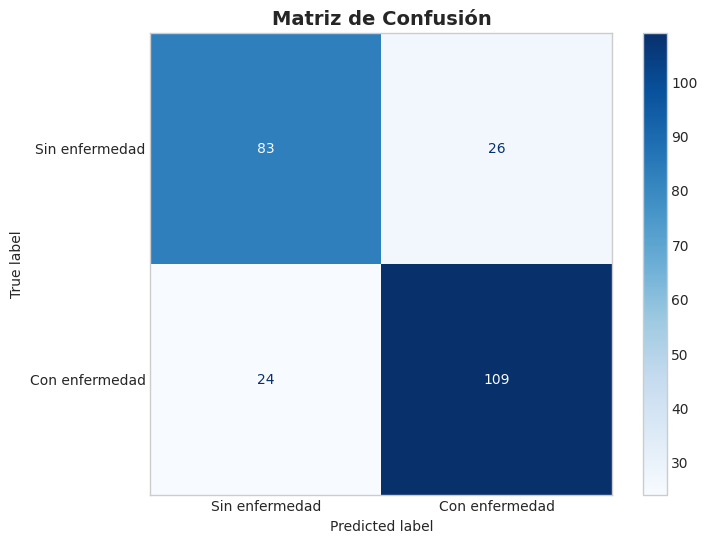

In [0]:
# TODO: Calcula y visualiza la matriz de confusión de Random Forest.
cm_rf = confusion_matrix(y_train, rf_preds)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_rf.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

# TODO: Compara los errores con los del modelo SGD.
# Comparado con SGD mejoro en los verdaderos neganitovs, ya que el número de falsos positivo disminuyó.

In [0]:
# TODO: Calcula métricas de Random Forest.
rf_precision = precision_score(y_train, rf_preds)
rf_recall = recall_score(y_train, rf_preds)
rf_f1 = f1_score(y_train, rf_preds)
rf_roc_auc = roc_auc_score(y_train, rf_preds)
print(f"Precision: {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"Recall: {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"F1 Score: {rf_f1:.4f}")
print(f"ROC-AUC Score: {rf_roc_auc:.4f}")


# TODO: Crea una tabla comparativa SGD vs Random Forest.
# TODO: Decide qué modelo funciona mejor y justifica tu respuesta.
print("\n SGD vs RANDOM FOREST")
comparison = pd.DataFrame({
    'Métrica': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'SGD': [precision, recall, f1, roc_auc],
    'Random Forest': [rf_precision, rf_recall, rf_f1, rf_roc_auc],
    'Diferencia': [
        rf_precision - precision,
        rf_recall - recall,
        rf_f1 - f1,
        rf_roc_auc - roc_auc
    ]
})
print(comparison.to_string(index=False))
# Random Forest presenta un mejor rendimiento general que SGD, ya que obtiene mayor Precision, F1-Score y ROC-AUC. Esto indica que comete menos falsos positivos y tiene una mejor capacidad global para distinguir entre las clases. Sin embargo, SGD obtiene un Recall ligeramente superior, por lo que detectanuna proporción un poco mayor de los pacientes realmente enfermos.

Precision: 0.8074 (80.74%)
Recall: 0.8195 (81.95%)
F1 Score: 0.8134
ROC-AUC Score: 0.7905

 SGD vs RANDOM FOREST
  Métrica      SGD  Random Forest  Diferencia
Precision 0.762238       0.807407    0.045170
   Recall 0.819549       0.819549    0.000000
 F1-Score 0.789855       0.813433    0.023578
  ROC-AUC 0.753811       0.790508    0.036697


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# TODO: Entrena el modelo final usando todo el conjunto de entrenamiento procesado.
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_train_pr, y_train)

# TODO: Explica por qué ahora entrenamos con todos los datos de train.
# Porque ya hemos evaluado y seleccionado el modelo mediante validación cruzada. Ahora podemos entrenar el modelo final utilizando todo el conjunto de entrenamiento, para que disponga de la mayor cantidad posible de datos antes de evaluarlo con test.


2026/09/27 15:53:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 15:53:57 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '6bc092d3434048a7b9a619cf20febc19', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/27 15:53:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/27 15:53:57 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/09/27 15:53:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

RandomForestClassifier(random_state=42)

In [0]:
# TODO: Separa características y target del conjunto de prueba.

x_test = test_set.drop("target", axis=1)
y_test = test_set.target
# TODO: Comprueba dimensiones.
print(f"X_test: {x_test.shape}")
print(f"y_test: {y_test.shape}")

X_test: (61, 13)
y_test: (61,)


In [0]:
# TODO: Transforma el conjunto de prueba y genera predicciones.
x_test_pr = full_pipeline.transform(x_test)
final_preds = forest_clf.predict(x_test_pr)

# TODO: Explica por qué usamos transform() y no fit_transform() en test.
# No debemos usar fit_transform en test porque el pipeline volvería a aprender parámetros a partir de los datos de test, como medias, medianas, desviaciones o categorías. Eso introduciría información del test en el preprocesamiento y provocaría data leakage. En test solo debemos usar transform(), aplicando exactamente las reglas aprendidas con train

2026/09/27 16:00:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


Accuracy: 0.8689 (86.89%)
Precision: 0.8750 (87.50%)
Recall: 0.8750 (87.50%)
F1 Score: 0.8750
ROC-AUC: 0.8685

 Matriz de Confusión Final:



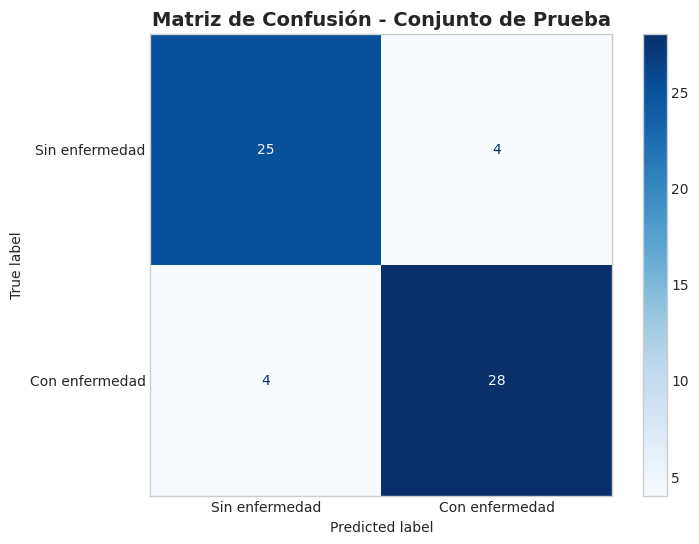

In [0]:
# TODO: Evalúa resultados finales en el conjunto de prueba.
final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)
final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_preds)
final_accuracy = accuracy_score(y_test, final_preds)

print(f"Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"Precision: {final_precision:.4f} ({final_precision*100:.2f}%)")
print(f"Recall: {final_recall:.4f} ({final_recall*100:.2f}%)")
print(f"F1 Score: {final_f1:.4f}")
print(f"ROC-AUC: {final_roc_auc:.4f}")

# TODO: Visualiza la matriz de confusión final.
# TODO: Genera classification_report.
# TODO: Interpreta si el modelo generaliza bien.
print("\n Matriz de Confusión Final:\n")
cm_final = confusion_matrix(y_test, final_preds)
disp_final = ConfusionMatrixDisplay(cm_final, display_labels=['Sin enfermedad', 'Con enfermedad'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_final.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Conjunto de Prueba', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

# El modelo parece generalizar bien porque obtiene métricas altas sobre el conjunto de test, formado por datos que no utilizó durante el entrenamiento.


## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración de datos médicos reales
2. [ ] Pipeline de preprocesamiento
3. [ ] Entrenamiento y comparación de modelos
4. [ ] Evaluación con métricas de clasificación
5. [ ] Validación cruzada
6. [ ] Registro de experimentos en MLflow
7. [ ] Interpretación de resultados con matrices de confusión

### 📊 Conclusiones Clave

**TODO: Basándote en tus resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - [Tu respuesta aquí]

2. **¿Por qué crees que funcionó mejor?**
   - [Tu respuesta aquí]

3. **¿El modelo es suficientemente bueno para uso médico?**
   - [Tu respuesta aquí]

4. **¿Qué métrica es más importante en este caso?**
   - [Tu respuesta aquí]

5. **¿Qué mejorarías del modelo?**
   - [Tu respuesta aquí]

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA

**TODO: Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - [Tu respuesta aquí]

2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - [Tu respuesta aquí]

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - [Tu respuesta aquí]

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del proyecto.

# ========================================
# TODO: DESAFÍO 1 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 2 - Curva ROC
# ========================================
# from sklearn.metrics import roc_curve, auc
# y_proba = ...
# fpr, tpr, thresholds = roc_curve(...)
# TODO: visualiza la curva ROC.

# ========================================
# TODO: DESAFÍO 3 - Importancia de características
# ========================================
# feature_names = ...
# feature_importance = ...
# TODO: identifica e interpreta las características más importantes.

# ========================================
# TODO: DESAFÍO 4 - Comparar más modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena, evalúa y registra cada modelo en MLflow
#     pass
